In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [45]:
df = pd.read_csv('dataset.csv')
X = df[['Luong', 'KinhNghiem']].values
y = df['ChoVay'].values

In [46]:
model = LogisticRegression(C=1e5)
model.fit(X, y) # type: ignore

w1, w2 = model.coef_[0]
b = model.intercept_[0]

new_case = np.array([[7, 1]])
prob_pass = model.predict_proba(new_case)[0][1]

print(f"w1={w1:.2f}, w2={w2:.2f}, b={b:.2f}")
print(f"Xác suất hồ sơ lương 7tr, 1 năm KN được duyệt: {prob_pass*100:.2f}")

w1=1.02, w2=3.07, b=-15.56
Xác suất hồ sơ lương 7tr, 1 năm KN được duyệt: 0.46


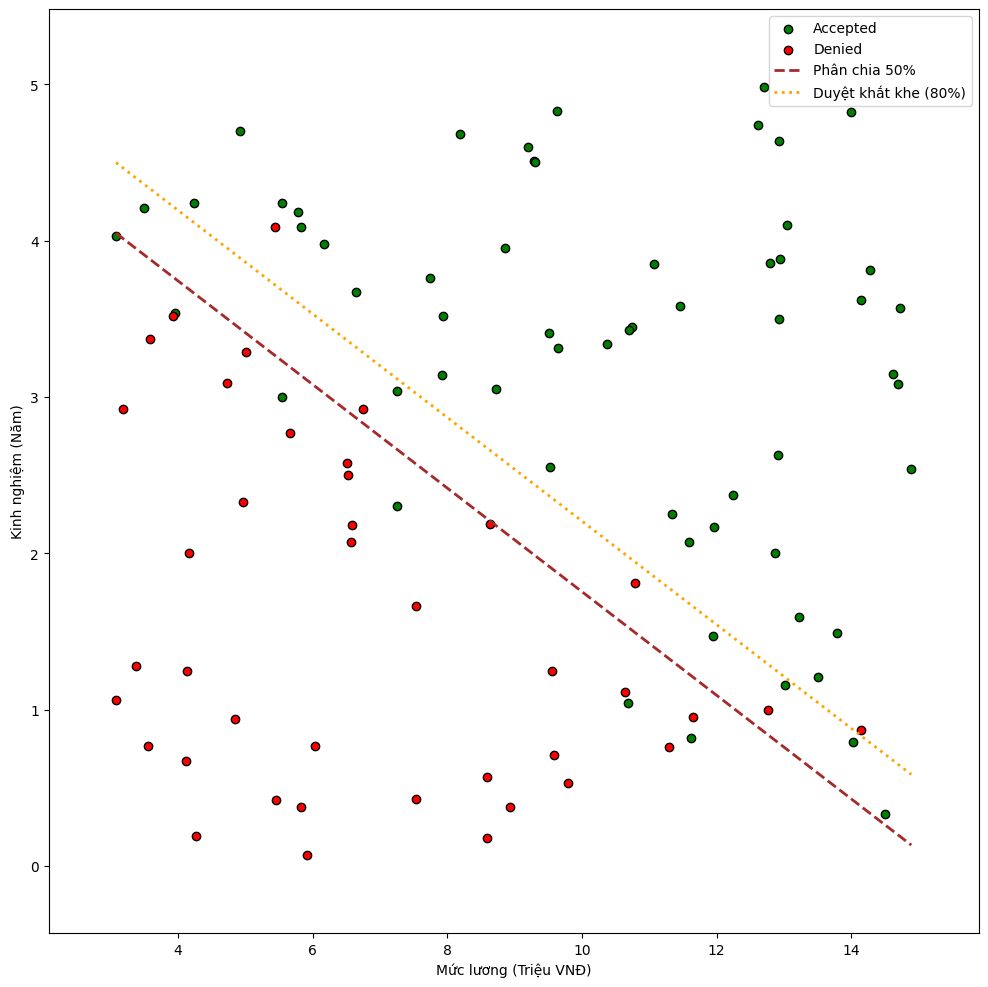

In [50]:
plt.figure(figsize=(12, 12))

plt.scatter(X[y==1, 0], X[y==1, 1], color='green', edgecolors='k', label='Accepted')
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', edgecolors='k', label='Denied')

x1_range = np.array([df['Luong'].min(), df['Luong'].max()])
x2_boundary = -(w1 * x1_range + b) / w2
plt.plot(x1_range, x2_boundary, color='brown', linestyle='--', linewidth=2, label='Phân chia 50%')

threshold_80 = np.log(0.8 / 0.2)
x2_boundary_80 = (threshold_80 - b - w1 * x1_range) / w2
plt.plot(x1_range, x2_boundary_80, color='orange', linestyle=':', linewidth=2, label='Duyệt khắt khe (80%)')

plt.xlabel('Mức lương (Triệu VNĐ)')
plt.ylabel('Kinh nghiệm (Năm)')
plt.legend()
plt.axis([df['Luong'].min()-1, df['Luong'].max()+1, df['KinhNghiem'].min()-0.5, df['KinhNghiem'].max()+0.5])

plt.show()